# Импорт библиотек

In [11]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from methods.linear_regression.regression import LinearRegression, PolynomialRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [12]:
SEED = 42

In [13]:
data = pd.read_csv("diamonds.csv")
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [14]:
print("Shape:", data.shape)
print("Columns:", list(data.columns))
print("Missing values:", int(data.isna().sum().sum()))

Shape: (53940, 11)
Columns: ['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
Missing values: 0


In [15]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

In [16]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [17]:
def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

# Линейная регрессия

In [18]:
X_full = data.drop(columns=["price"])
y = data["price"].to_numpy(dtype=float)

X_full_encoded = pd.get_dummies(X_full, drop_first=True)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full_encoded.to_numpy(dtype=float), y, test_size=0.2, random_state=SEED
)

print("Encoded features:", X_train.shape[1])
print("Train/Test:", X_train.shape, X_test.shape)

Encoded features: 24
Train/Test: (43152, 24) (10788, 24)


In [20]:
linear_custom = LinearRegression().fit(X_train, y_train)
y_pred_linear_custom = linear_custom.predict(X_test)

linear_sk = SklearnLinearRegression().fit(X_train, y_train)
y_pred_linear_sk = linear_sk.predict(X_test)

In [21]:
X_train_design = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_design = np.c_[np.ones(X_test.shape[0]), X_test]
params, *_ = np.linalg.lstsq(X_train_design, y_train, rcond=None)
y_pred_linear_lstsq = X_test_design @ params

In [22]:
linear_results = pd.DataFrame([
    {"method": "Linear custom", "MAE": mae(y_test, y_pred_linear_custom), "RMSE": rmse(y_test, y_pred_linear_custom), "R2": r2(y_test, y_pred_linear_custom)},
    {"method": "Linear sklearn", "MAE": mae(y_test, y_pred_linear_sk), "RMSE": rmse(y_test, y_pred_linear_sk), "R2": r2(y_test, y_pred_linear_sk)},
    {"method": "Linear numpy lstsq", "MAE": mae(y_test, y_pred_linear_lstsq), "RMSE": rmse(y_test, y_pred_linear_lstsq), "R2": r2(y_test, y_pred_linear_lstsq)},
])

linear_results

,method,MAE,RMSE,R2
0,Linear custom,737.135361,1132.359457,0.91934
1,Linear sklearn,737.135361,1132.359457,0.91934
2,Linear numpy lstsq,737.135361,1132.359457,0.91934


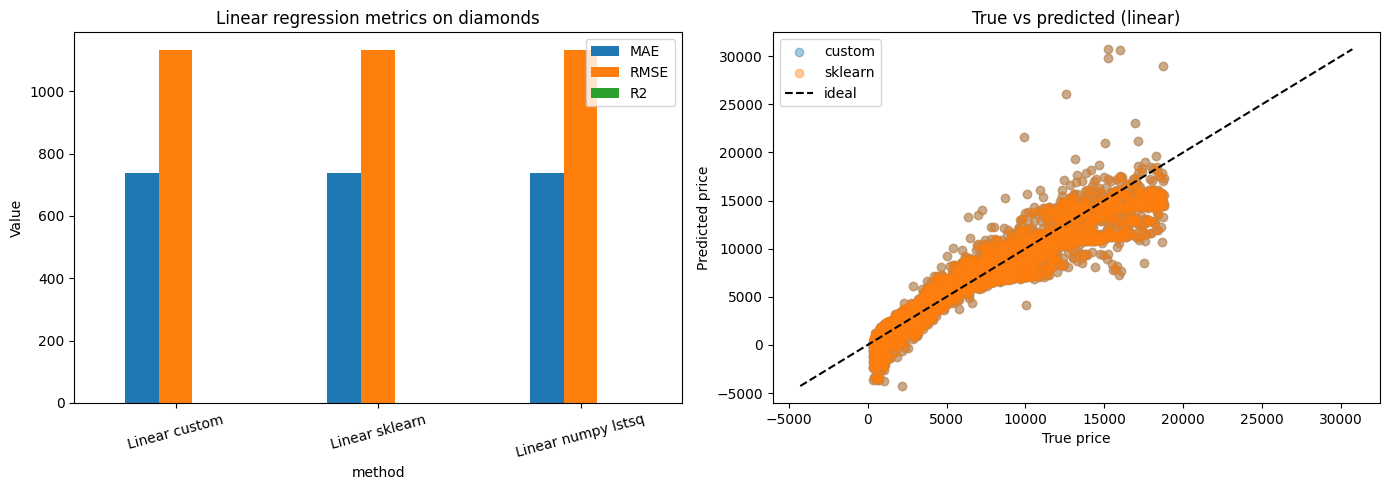

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

linear_results.set_index("method")[["MAE", "RMSE", "R2"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Linear regression metrics on diamonds")
axes[0].set_ylabel("Value")

axes[1].scatter(y_test, y_pred_linear_custom, alpha=0.4, label="custom")
axes[1].scatter(y_test, y_pred_linear_sk, alpha=0.4, label="sklearn")
min_v = float(min(y_test.min(), y_pred_linear_custom.min(), y_pred_linear_sk.min()))
max_v = float(max(y_test.max(), y_pred_linear_custom.max(), y_pred_linear_sk.max()))
axes[1].plot([min_v, max_v], [min_v, max_v], "k--", label="ideal")
axes[1].set_title("True vs predicted (linear)")
axes[1].set_xlabel("True price")
axes[1].set_ylabel("Predicted price")
axes[1].legend()

plt.tight_layout()
plt.show()

## Полиномиальная регрессия (числовые признаки)

In [24]:
numeric_cols = ["carat", "depth", "table", "x", "y", "z"]
X_num = data[numeric_cols].to_numpy(dtype=float)
y = data["price"].to_numpy(dtype=float)

In [25]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y, test_size=0.2, random_state=SEED
)

In [26]:
degree = 2

In [27]:
poly_custom = PolynomialRegression(degree=degree).fit(X_train_num, y_train_num)
y_pred_poly_custom = poly_custom.predict(X_test_num)

In [28]:
pf = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = pf.fit_transform(X_train_num)
X_test_poly = pf.transform(X_test_num)
poly_sk = SklearnLinearRegression().fit(X_train_poly, y_train_num)
y_pred_poly_sk = poly_sk.predict(X_test_poly)

In [29]:
poly_results = pd.DataFrame([
    {"method": "Polynomial custom (d=2)", "MAE": mae(y_test_num, y_pred_poly_custom), "RMSE": rmse(y_test_num, y_pred_poly_custom), "R2": r2(y_test_num, y_pred_poly_custom)},
    {"method": "Polynomial sklearn (d=2)", "MAE": mae(y_test_num, y_pred_poly_sk), "RMSE": rmse(y_test_num, y_pred_poly_sk), "R2": r2(y_test_num, y_pred_poly_sk)},
])

poly_results

,method,MAE,RMSE,R2
0,Polynomial custom (d=2),820.107009,1391.405562,0.878214
1,Polynomial sklearn (d=2),820.107086,1391.405578,0.878214


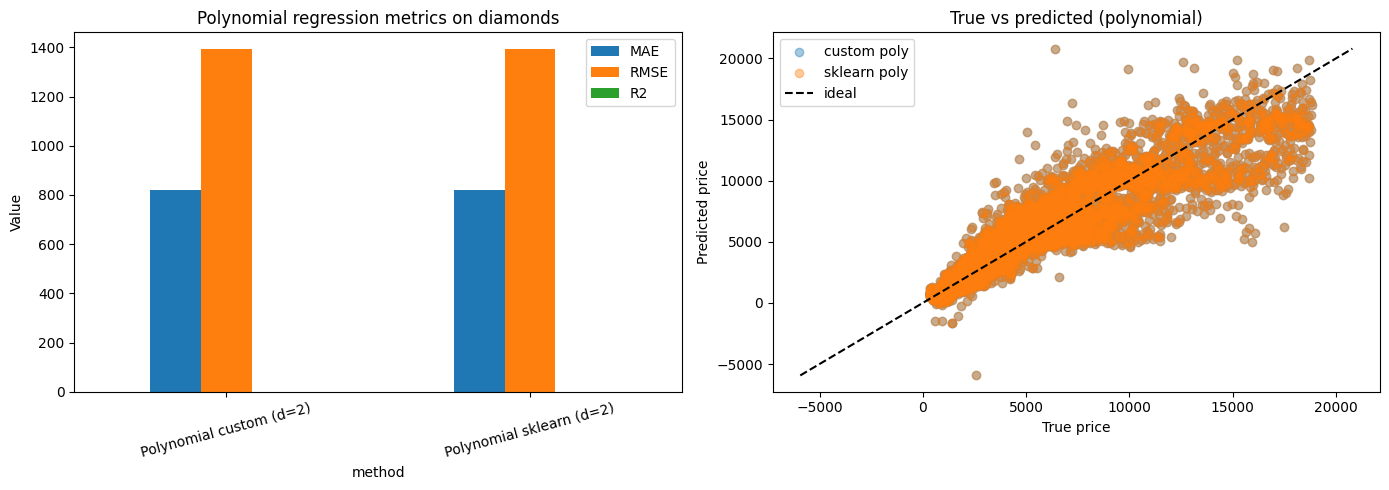

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

poly_results.set_index("method")[["MAE", "RMSE", "R2"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Polynomial regression metrics on diamonds")
axes[0].set_ylabel("Value")

axes[1].scatter(y_test_num, y_pred_poly_custom, alpha=0.4, label="custom poly")
axes[1].scatter(y_test_num, y_pred_poly_sk, alpha=0.4, label="sklearn poly")
min_v = float(min(y_test_num.min(), y_pred_poly_custom.min(), y_pred_poly_sk.min()))
max_v = float(max(y_test_num.max(), y_pred_poly_custom.max(), y_pred_poly_sk.max()))
axes[1].plot([min_v, max_v], [min_v, max_v], "k--", label="ideal")
axes[1].set_title("True vs predicted (polynomial)")
axes[1].set_xlabel("True price")
axes[1].set_ylabel("Predicted price")
axes[1].legend()

plt.tight_layout()
plt.show()